## Análise de outliers

In [1]:
# gerais
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# aplicacao
from sklearn.preprocessing import scale
from sklearn.covariance import EmpiricalCovariance, MinCovDet

In [9]:
import pandas as pd

arquivos = [
    'vendas_linha_petshop_2019.csv',
    'vendas_linha_petshop_2020.csv',
    'vendas_linha_petshop_2021.csv',
    'vendas_linha_petshop_2022.csv'
]

dfs = []

for arq in arquivos:
    df = pd.read_csv(arq, sep=';', decimal=',', encoding='latin1', on_bad_lines='skip')
    dfs.append(df)

# concatenar
vendas_totais = pd.concat(dfs, ignore_index=True)

# visualizar
vendas_totais.head()

,cod_pedido,regiao_pais,produto,valor,quantidade,valor_total_bruto,data,estado,formapagto,centro_distribuicao,responsavelpedido,valor_comissao,lucro_liquido,categoriaprod
0,1,Norte,Biscoito True Champion 300g,22.0,2.0,44.0,13/06/2019,Acre,Dinheiro,Rapid Pink,Carlos,0.44,17.6,Alimentação
1,2,Norte,Biscoito True Champion 300g,21.0,2.0,42.0,03/01/2019,Amapá,Pix,Rapid Pink,Maria Linda,0.42,16.8,Alimentação
2,3,Norte,Biscoito True Champion 300g,22.0,NaN,44.0,18/01/2019,Pará,Boleto Bancário,Rapid Pink,Julia,0.88,35.2,Alimentação
3,4,Norte,Biscoito True Champion 300g,19.0,4.0,88.0,19/08/2019,Rondônia,Boleto Bancário,Rapid Pink,Yuri,0.76,30.4,Alimentação
4,5,Norte,Biscoito True Champion 300g,22.0,2.0,44.0,18/10/2019,Tocantins,Cartão Crédito,Rapid Pink,Dolores,0.44,17.6,Alimentação


In [14]:
vendas_totais.shape

(200786, 15)

## Método Score-z

In [12]:
import numpy as np
# Convert 'quantidade' to numeric, coercing errors to NaN
vendas_totais['quantidade'] = pd.to_numeric(vendas_totais['quantidade'], errors='coerce')
# Fill NaN values with the median of the 'quantidade' column
vendas_totais['quantidade'] = vendas_totais['quantidade'].fillna(vendas_totais['quantidade'].median())
# Now apply the scale function
vendas_totais['quantidade_z'] = scale(vendas_totais['quantidade'])

In [17]:
vendas_totais[['quantidade', 'quantidade_z']].head()

,quantidade,quantidade_z
0,2.0,-0.136524
1,2.0,-0.136524
2,1.0,-0.219677
3,4.0,0.029783
4,2.0,-0.136524


In [15]:
vendas_totais[['quantidade', 'quantidade_z']].describe()

,quantidade,quantidade_z
count,200786.000000,2.007860e+05
mean,3.641833,1.811869e-17
std,12.026001,1.000002e+00
min,0.000000,-3.028307e-01
25%,1.000000,-2.196773e-01
50%,1.000000,-2.196773e-01
75%,2.000000,-1.365239e-01
max,110.000000,8.844040e+00


In [20]:
vendas_totais.sort_values('quantidade_z', ascending = False)

,cod_pedido,regiao_pais,produto,valor,quantidade,valor_total_bruto,data,estado,formapagto,centro_distribuicao,responsavelpedido,valor_comissao,lucro_liquido,categoriaprod,quantidade_z
27886,27887,Norte,"Ração Royal Canin Exigent Gatos Adultos 1,5Kg",100.00,110.0,11000.00,23/09/2019,Rondônia,Cartão Crédito,Rapid Pink,Yuri,215.60,5390.0,Alimentação,8.844040
20427,20428,Sudeste,Roupa para Gato Petti,28.00,110.0,3080.00,26/01/2019,Minas Gerais,Cartão Débito,Papa Léguas,Monique,148.50,2574.0,Acessório,8.844040
22860,22861,Norte,Vitamina E Granulado BigForce,69.00,110.0,7590.00,09/08/2019,Pará,Boleto Bancário,Rapid Pink,Julia,343.20,4719.0,Medicamento,8.844040
22877,22878,Sudeste,Vitamina E Granulado BigForce,56.00,110.0,6160.00,08/04/2019,Minas Gerais,Cartão Crédito,Papa Léguas,Monique,330.00,4537.5,Medicamento,8.844040
22629,22630,Sudeste,Meias esportivas para cães para ambientes inte...,32.00,110.0,3520.00,11/02/2019,Espírito Santo,Dinheiro,Papa Léguas,Tereza,140.80,1408.0,Acessório,8.844040
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
86647,86648,Sudeste,Biscoito Pedigree Biscrok Multi para Cães Adul...,30.24,1.0,30.24,18/07/2020,Rio de Janeiro,Boleto Bancário,Papa Léguas,Antonio,0.81,8.4,Petisco,-0.219677
86644,86645,Sudeste,Biscoito Pedigree Biscrok Multi para Cães Adul...,34.72,1.0,34.72,15/10/2020,Piauí,Cartão Débito,Gold Beach,Cristian,0.90,8.4,Petisco,-0.219677
86642,86643,Nordeste,Biscoito Pedigree Biscrok Multi para Cães Adul...,33.60,1.0,33.60,12/12/2020,Paraíba,Boleto Bancário,Gold Beach,Cristina,0.84,8.7,Petisco,-0.219677
86667,86668,Nordeste,Whiskas Petisco Temptations Anti Bola de Pelo 40g,5.60,1.0,5.60,19/05/2020,Paraíba,Pix,Gold Beach,Cristina,0.18,1.5,Petisco,-0.219677


<Axes: >

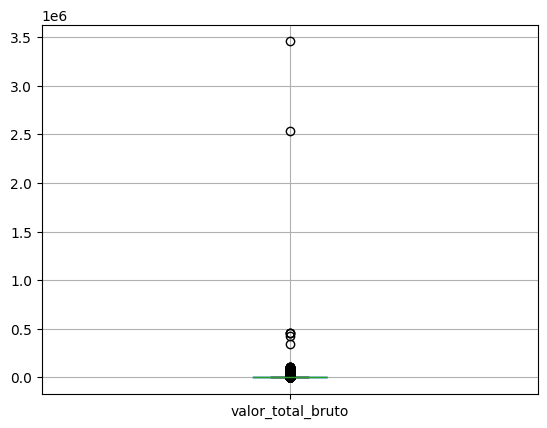

In [32]:
vendas_totais[['valor_total_bruto']].boxplot()

<Axes: xlabel='quantidade', ylabel='valor_total_bruto'>

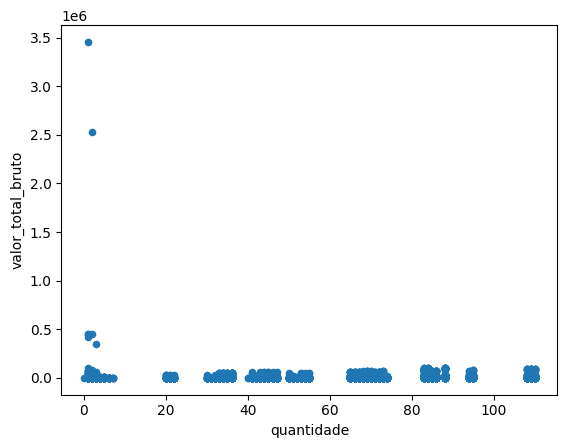

In [28]:
vendas_totais.plot.scatter(x = 'quantidade', y = 'valor_total_bruto')

Sim, existem outliers no conjunto de dados. No gráfico de dispersão, observa-se que algumas vendas apresentam valores de valor_total_bruto extremamente elevados em comparação com a maioria das observações. Esses valores estão associados a quantidades muito baixas, o que sugere vendas atípicas de alto valor ou possíveis inconsistências nos dados. Esses pontos destoam significativamente da distribuição principal e devem ser investigados antes de análises mais profundas.

In [29]:
import numpy as np
# Convert 'quantidade' to numeric, coercing errors to NaN
vendas_totais['valor_total_bruto'] = pd.to_numeric(vendas_totais['valor_total_bruto'], errors='coerce')
# Fill NaN values with the median of the 'quantidade' column
vendas_totais['valor_total_bruto'] = vendas_totais['valor_total_bruto'].fillna(vendas_totais['valor_total_bruto'].median())
# Now apply the scale function
vendas_totais['valor_total_bruto_z'] = scale(vendas_totais['valor_total_bruto'])

In [30]:
vendas_totais.sort_values('valor_total_bruto_z', ascending = False)

,cod_pedido,regiao_pais,produto,valor,quantidade,valor_total_bruto,data,estado,formapagto,centro_distribuicao,responsavelpedido,valor_comissao,lucro_liquido,categoriaprod,quantidade_z,valor_total_bruto_z
151224,151419,Nordeste,Suplemento Alimentar Glutamina Mundo Animal Nu...,59.94,1.0,3456346.0,25/01/2022,Ceará,Boleto Bancário,Gold Beach,Neide,1.48,20.35,Medicamento,-0.219677,338.244915
150394,150589,Centro Oeste,Biscoito True Champion 300g,42.12,2.0,2534234.0,14/04/2022,Mato Grosso,Boleto Bancário,Grãos Blue,Andressa,0.52,20.80,Alimentação,-0.136524,247.994203
1697,1698,Nordeste,Biscoito True Champion 300g,20.00,2.0,456546.0,15/05/2019,Maranhão,Cartão Débito,Gold Beach,Clarice,0.80,16.00,Alimentação,-0.136524,44.642743
1752,1753,Sudeste,Cama média almofadada Pity,52.00,1.0,456456.0,11/04/2019,Minas Gerais,Boleto Bancário,Papa Léguas,Monique,0.49,29.40,Acessório,-0.219677,44.633934
1622,1623,Nordeste,Meias esportivas para cães para ambientes inte...,33.00,1.0,456456.0,30/04/2019,Maranhão,Cartão Débito,Gold Beach,Clarice,1.32,13.20,Acessório,-0.219677,44.633934
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64,65,Nordeste,Cama média almofadada Pity,62.00,1.0,0.0,14/03/2019,Maranhão,Cartão Débito,Gold Beach,Clarice,0.49,29.40,Acessório,-0.219677,-0.041202
55,56,Norte,Cama média almofadada Pity,51.00,1.0,0.0,06/06/2019,Roraima,Pix,Rapid Pink,Adriana,0.54,32.40,Acessório,-0.219677,-0.041202
50379,50380,Centro Oeste,Mordedor de Corda Bola,12.32,1.0,0.0,11/02/2020,Mato Grosso do Sul,Cartão Crédito,Grãos Blue,Ligia,0.44,6.60,Brinquedo,-0.219677,-0.041202
26,27,Norte,Bola Pet Vinil Big Blue,22.00,1.0,0.0,01/04/2019,Amapá,Cartão Crédito,Rapid Pink,Maria Linda,0.22,8.80,Brinquedo,-0.219677,-0.041202


## Tratamento outliers

In [33]:
vendas_totais['quantidade'].quantile([0.05, 0.9])

,quantidade
0.05,1.0
0.90,3.0


### guardar estes valores

In [34]:
wins_values = vendas_totais['quantidade'].quantile([0.05, 0.9]).to_list()

In [35]:
np.round(wins_values, 2)

array([1., 3.])

In [36]:
vendas_totais['quantidade_wins'] = vendas_totais['quantidade'] \
                                        .clip(wins_values[0], wins_values[1])

In [38]:
vendas_totais[['cod_pedido', 'quantidade', 'quantidade_wins']] \
    .sort_values(by='quantidade', ascending=False) \
    .head(10)

,cod_pedido,quantidade,quantidade_wins
27886,27887,110.0,3.0
20427,20428,110.0,3.0
22860,22861,110.0,3.0
22877,22878,110.0,3.0
22629,22630,110.0,3.0
22501,22502,110.0,3.0
19940,19941,110.0,3.0
25769,25770,110.0,3.0
25868,25869,110.0,3.0
19337,19338,110.0,3.0


<Axes: >

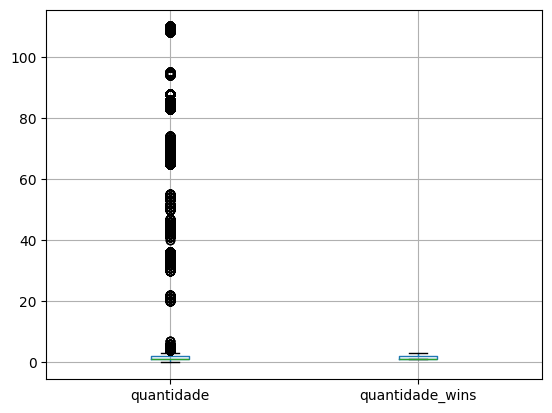

In [39]:
vendas_totais[['quantidade', 'quantidade_wins']].boxplot()

## Estimativa de variablidade

In [55]:
import numpy as np
# Cálculo do Desvio Padrão
desvio_padrao = np.std(vendas_totais['quantidade_wins'], ddof=1) # ddof=1 para usar a fórmula da amostra
print(f"Desvio Padrão: {desvio_padrao}")

Desvio Padrão: 0.8209544042298312


In [53]:
# Exemplo de dados
dados = vendas_totais['quantidade_wins'] # Exemplo com um outlier
# Valores mínimo e máximo
minimo = min(dados)
maximo = max(dados)
print(f"Valor Mínimo: {minimo}, Valor Máximo: {maximo}")

Valor Mínimo: 1.0, Valor Máximo: 3.0


Um desvio padrão de 0.82 é relativamente baixo em comparação com a escala total de 0 a 110. A baixa variabilidade indica que os dados não estão muito dispersos, o que pode ser um sinal de consistência após o tratamento dos outliers.

In [43]:
vendas_totais['valor_total_bruto'].quantile([0.05, 0.9])

,valor_total_bruto
0.05,15.68
0.90,692.16


In [45]:
wins_values = vendas_totais['valor_total_bruto'].quantile([0.05, 0.9]).to_list()

In [46]:
np.round(wins_values, 2)

array([ 15.68, 692.16])

In [47]:
vendas_totais['valor_total_bruto_wins'] = vendas_totais['valor_total_bruto'] \
                                        .clip(wins_values[0], wins_values[1])

In [49]:
vendas_totais[['cod_pedido', 'valor_total_bruto', 'valor_total_bruto_wins']] \
    .sort_values(by='valor_total_bruto', ascending=False) \
    .head(10)

,cod_pedido,valor_total_bruto,valor_total_bruto_wins
151224,151419,3456346.00,692.16
150394,150589,2534234.00,692.16
1697,1698,456546.00,692.16
1752,1753,456456.00,692.16
1622,1623,456456.00,692.16
794,795,423142.00,692.16
106600,106795,345345.00,692.16
144178,144373,104165.60,692.16
149537,149732,104165.60,692.16
148379,148574,102527.04,692.16


<Axes: >

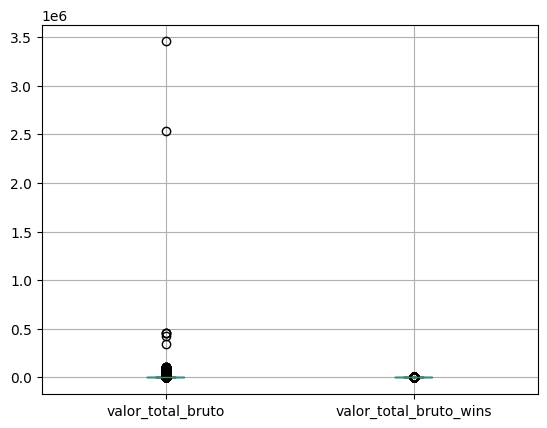

In [50]:
vendas_totais[['valor_total_bruto', 'valor_total_bruto_wins']].boxplot()